# Exploratory data analysis (EDA) II
## Analysis between 2 or more variables


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('DataSet/dataset_countries.csv')

df = df[df['year'] >= 1950].copy()

bins = list(range(1950, 2031, 10))
labels = [f'{b}-{b+9}' for b in bins[:-1]]
df['period'] = pd.cut(df['year'], bins=bins, labels=labels, right=False)

print(f'Shape: {df.shape}')
print(f'Períodos: {df["period"].cat.categories.tolist()}')
df.head()

Shape: (17390, 8)
Períodos: ['1950-1959', '1960-1969', '1970-1979', '1980-1989', '1990-1999', '2000-2009', '2010-2019', '2020-2029']


,entity,code,year,child_mortality_rate,fertility_rate_hist,continent,sub_region,period
0,Afghanistan,AFG,1950,37.13,7.248,Asia,Southern Asia,1950-1959
1,Afghanistan,AFG,1951,37.13,7.260,Asia,Southern Asia,1950-1959
2,Afghanistan,AFG,1952,37.13,7.260,Asia,Southern Asia,1950-1959
3,Afghanistan,AFG,1953,37.13,7.266,Asia,Southern Asia,1950-1959
4,Afghanistan,AFG,1954,37.13,7.254,Asia,Southern Asia,1950-1959


In [12]:
countries = ['Brazil', 'Japan', 'Nigeria', 'Sweden', 'India']
df_sample = df[df['entity'].isin(countries)].copy()

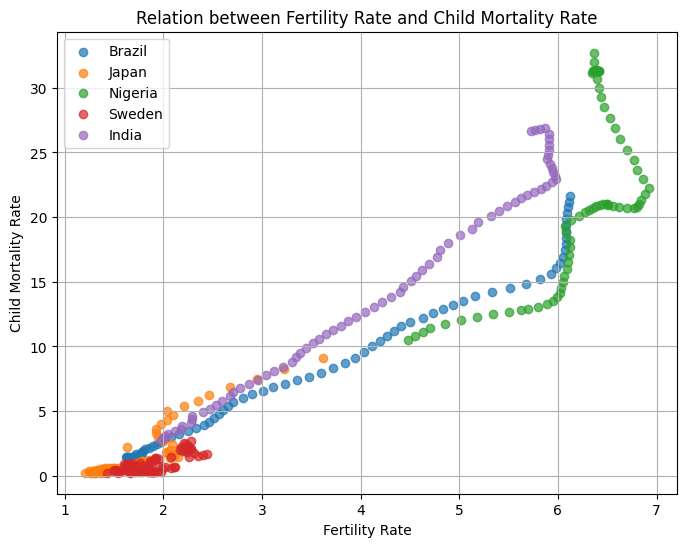

In [13]:
plt.figure(figsize=(8,6))

for country in countries:
    subset = df_sample[df_sample['entity'] == country]
    plt.scatter(
        subset['fertility_rate_hist'],
        subset['child_mortality_rate'],
        label=country,
        alpha=0.7
    )

plt.xlabel('Fertility Rate')
plt.ylabel('Child Mortality Rate')
plt.title('Relation between Fertility Rate and Child Mortality Rate')
plt.legend()
plt.grid(True)

plt.show()

C:\Users\deant\AppData\Local\Temp\ipykernel_25256\1585852220.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_sample.groupby(['entity', 'period'])[


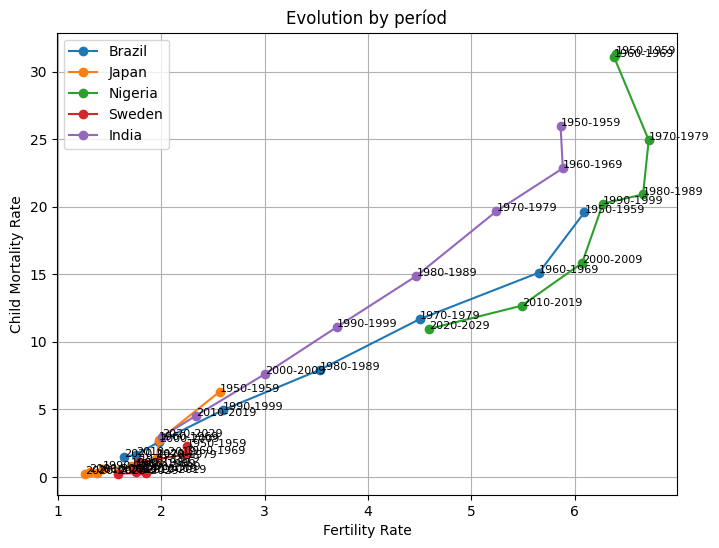

In [15]:
grouped = df_sample.groupby(['entity', 'period'])[
    ['child_mortality_rate', 'fertility_rate_hist']
].mean().reset_index()
plt.figure(figsize=(8,6))

for country in countries:
    subset = grouped[grouped['entity'] == country]

    plt.plot(
        subset['fertility_rate_hist'],
        subset['child_mortality_rate'],
        marker='o',
        label=country
    )
    for _, row in subset.iterrows():
        plt.text(
            row['fertility_rate_hist'],
            row['child_mortality_rate'],
            str(row['period']),
            fontsize=8
    )


plt.xlabel('Fertility Rate')
plt.ylabel('Child Mortality Rate')
plt.title('Evolution by períod')
plt.legend()
plt.grid(True)

plt.show()

## Conclusion
It is perceptible there is a strong, positive correlation between child mortality and fertility rates.
The relation, however, between child mortality and fertility rates, and time is negative.